# 02. Named Circuit 与可复用线路

用命名寄存器和 `@circuit_def` 组织可复用子线路，再组合成一个 4-qubit GHZ-like 电路。


In [1]:
import math
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from uniqc import Circuit
from uniqc.simulator import OriginIR_Simulator


def probability_dict(values):
    if isinstance(values, dict):
        total = sum(values.values()) or 1
        return {format(int(k), "b") if isinstance(k, int) else str(k): v / total for k, v in values.items()}
    n = int(math.log2(len(values))) if values else 0
    return {format(i, f"0{n}b"): float(p) for i, p in enumerate(values) if abs(float(p)) > 1e-12}


def plot_probs(probs, title):
    labels = list(probs)
    values = [probs[k] for k in labels]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(labels, values, color="#3267a8")
    ax.set_ylim(0, max(1.0, max(values, default=0) * 1.2))
    ax.set_xlabel("bitstring")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()


DEF export:
DEF bell_pair(q[0], q[1])
H q[0]
CNOT q[0], q[1]
ENDDEF
operations: 9
non-zero states: {'0000': 0.24999999999999978, '0111': 0.2499999999999998, '1011': 0.24999999999999986, '1100': 0.24999999999999983}


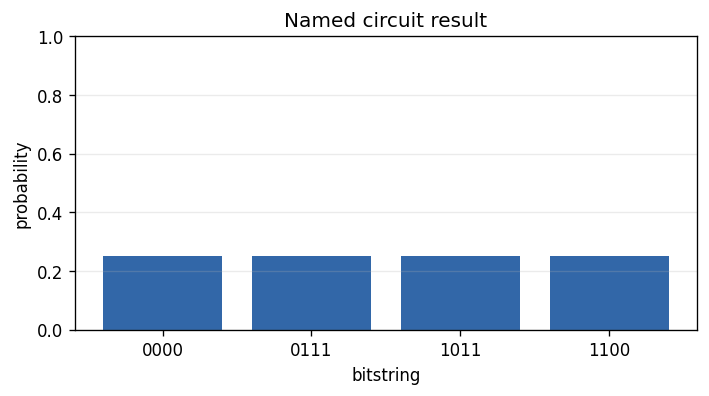

In [2]:
from uniqc import circuit_def

@circuit_def(name="bell_pair", qregs={"q": 2})
def bell_pair(circ, q):
    circ.h(q[0])
    circ.cnot(q[0], q[1])
    return circ

@circuit_def(name="rz_layer", qregs={"q": 4}, params=["angle"])
def rz_layer(circ, q, angle):
    for i in range(4):
        circ.rz(q[i], angle)
    return circ

circuit = Circuit(qregs={"data": 4})
data = circuit.get_qreg("data")

bell_pair(circuit, qreg_mapping={"q": [data[0], data[1]]})
bell_pair(circuit, qreg_mapping={"q": [data[2], data[3]]})
circuit.cnot(data[1], data[2])
rz_layer(circuit, qreg_mapping={"q": [data[0], data[1], data[2], data[3]]}, param_values={"angle": 0.25})
circuit.measure(0, 1, 2, 3)

print("DEF export:")
print(bell_pair.to_originir_def())
print("operations:", len(circuit.opcode_list))

probs = probability_dict(OriginIR_Simulator().simulate_pmeasure(circuit.originir))
print("non-zero states:", probs)
plot_probs(probs, "Named circuit result")
